# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [1]:
import pandas as pd
data_frame = pd.read_csv("delivery_dataset.csv")
data_frame.head(5)

,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [2]:
features = [
    "Расстояние до клиента (в км)",
    "Количество позиций в чеке (в шт.)",
    "Балл пробок на дорогах (в баллах)",
    "Погода (в градусах Цельсия)",
    "Этаж доставки (в этажах)"
]
# Признаки используются для предсказания времени доставки.
x = data_frame[features]
y = data_frame["Время доставки (в минутах)"]

# Делим данные строго по порядку строк, как указано в задании.
x_train, y_train = x.iloc[:300], y.iloc[:300]
x_val, y_val = x.iloc[300:400], y.iloc[300:400]
x_test, y_test = x.iloc[400:500], y.iloc[400:500]


#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [3]:
!pip install scikit-learn

  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 4.6 MB/s  0:00:01m0:00:0100:01m
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 2.2 MB/s  0:00:09m0:00:0100:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [4]:
# Ваш код
from sklearn.linear_model import Ridge

# sparse_cg — итерационный метод решения задачи Ridge.
model = Ridge(alpha=1.0, solver="sparse_cg", max_iter=1000, tol=1e-6)
model.fit(x_train, y_train)

,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",1000
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",1e-06
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'sparse_cg'
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'sa

#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

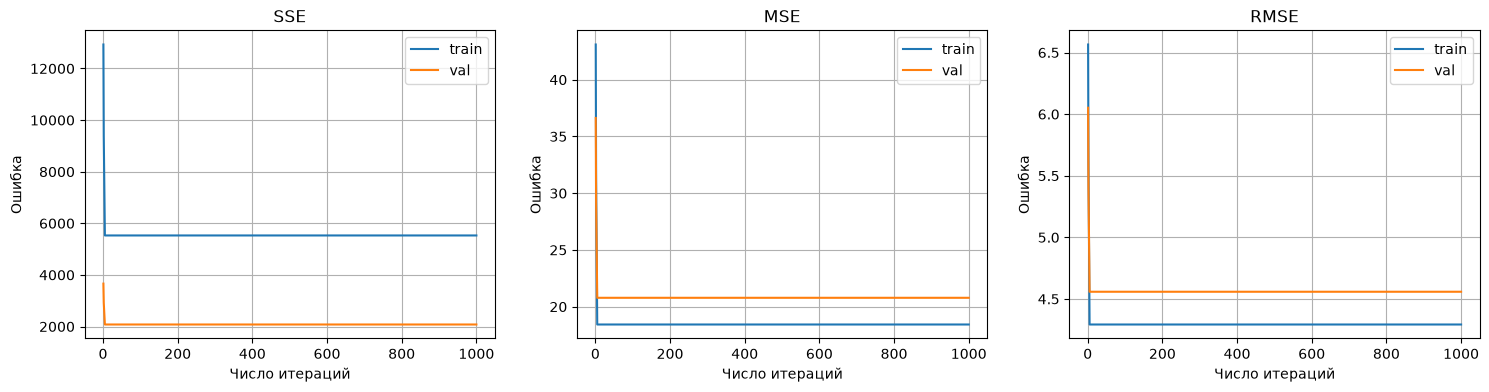

In [6]:
# Ваш код
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

iterations = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
train_sse, val_sse = [], []
train_mse, val_mse = [], []
train_rmse, val_rmse = [], []

# Обучаем отдельную модель для каждого лимита итераций.
for max_iter in iterations:
    current_model = Ridge(alpha=1.0, solver="sparse_cg", max_iter=max_iter, tol=1e-6)
    current_model.fit(x_train, y_train)

    train_predictions = current_model.predict(x_train)
    val_predictions = current_model.predict(x_val)

    current_train_mse = mean_squared_error(y_train, train_predictions)
    current_val_mse = mean_squared_error(y_val, val_predictions)

    # SSE — сумма квадратов ошибок, MSE — её среднее, RMSE — корень из MSE.
    train_sse.append(current_train_mse * len(y_train))
    val_sse.append(current_val_mse * len(y_val))
    train_mse.append(current_train_mse)
    val_mse.append(current_val_mse)
    train_rmse.append(current_train_mse ** 0.5)
    val_rmse.append(current_val_mse ** 0.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for axis, train_errors, val_errors, metric_name in zip(
    axes,
    [train_sse, train_mse, train_rmse],
    [val_sse, val_mse, val_rmse],
    ["SSE", "MSE", "RMSE"]
):
    axis.plot(iterations, train_errors, label="train")
    axis.plot(iterations, val_errors, label="val")
    axis.set_title(metric_name)
    axis.set_xlabel("Число итераций")
    axis.set_ylabel("Ошибка")
    axis.legend()
    axis.grid()

plt.show()

#### Шаг 6. Применение модели на тестовой выборке

In [7]:
# Ваш код
# Получаем прогнозы модели, обученной на тренировочной выборке.
test_predictions = model.predict(x_test)
test_predictions[:5]

array([33.06377425, 33.12797249, 20.85154386, 34.38841872, 17.56463048])

#### Шаг 7. RMSE на тестовой выборке

In [8]:
# Ваш код
# RMSE измеряется в тех же минутах, что и целевая переменная.
test_rmse = mean_squared_error(y_test, test_predictions) ** 0.5
print(f"RMSE на тестовой выборке: {test_rmse:.2f}")

RMSE на тестовой выборке: 4.83
